In [3]:
import pandas as pd

# Charger le fichier CSV
df = pd.read_csv('out.csv')

In [4]:
print(df.isnull().sum())

Num_Facture            0
NATURE                 0
Intitule_Nature        0
ID_Client              0
Date                   0
Categories_produits    0
Brut                   0
Remise                 0
Net_HT                 0
Cout_de_revient        0
TVA                    0
Timbre                 0
Net_TTC                0
Benefice               0
Taux_Marge             0
TVA_PCT                0
dtype: int64


In [5]:
df = df[['Num_Facture', 'Date']]
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_counts = df.groupby('YearMonth').size().reset_index(name='Num_Factures')
monthly_counts['YearMonth'] = monthly_counts['YearMonth'].dt.to_timestamp()

from prophet import Prophet

# Préparer les données pour Prophet
prophet_df = monthly_counts.rename(columns={'YearMonth': 'ds', 'Num_Factures': 'y'})

# Initialiser et entraîner le modèle
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_df)

# Créer un DataFrame pour les prédictions futures (par exemple, 12 mois)
future = prophet_model.make_future_dataframe(periods=12, freq='M')
forecast = prophet_model.predict(future)

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# Vérifier la stationnarité avec le test ADF
result = adfuller(monthly_counts['Num_Factures'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# Si non stationnaire, différencier les données
diff_data = monthly_counts['Num_Factures'].diff().dropna()

# Entraîner ARIMA (ordre à déterminer via ACF/PACF ou grid search)
arima_model = ARIMA(monthly_counts['Num_Factures'], order=(1, 1, 1))
arima_fit = arima_model.fit()

# Prédire pour les 12 prochains mois
arima_forecast = arima_fit.forecast(steps=12)


from statsmodels.tsa.statespace.sarimax import SARIMAX

# Entraîner SARIMA
sarima_model = SARIMAX(monthly_counts['Num_Factures'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_fit = sarima_model.fit(disp=False)

# Prédire pour les 12 prochains mois
sarima_forecast = sarima_fit.forecast(steps=12)

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Diviser les données
train_size = int(len(monthly_counts) * 0.8)
train, test = monthly_counts[:train_size], monthly_counts[train_size:]

# Fonction pour calculer les métriques
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    return rmse, mae, mse

# Évaluation de Prophet
prophet_train = train.rename(columns={'YearMonth': 'ds', 'Num_Factures': 'y'})
prophet_model = Prophet(yearly_seasonality=True).fit(prophet_train)
future = prophet_model.make_future_dataframe(periods=len(test), freq='M')
prophet_pred = prophet_model.predict(future)[-len(test):]['yhat']
prophet_rmse, prophet_mae, prophet_mse = evaluate_model(test['Num_Factures'], prophet_pred)

# Évaluation de ARIMA
arima_model = ARIMA(train['Num_Factures'], order=(1, 1, 1)).fit()
arima_pred = arima_model.forecast(steps=len(test))
arima_rmse, arima_mae, arima_mse = evaluate_model(test['Num_Factures'], arima_pred)

# Évaluation de SARIMA
sarima_model = SARIMAX(train['Num_Factures'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
sarima_pred = sarima_model.forecast(steps=len(test))
sarima_rmse, sarima_mae, sarima_mse = evaluate_model(test['Num_Factures'], sarima_pred)



<ipython-input-5-0824c1225004>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date'] = pd.to_datetime(df['Date'])
<ipython-input-5-0824c1225004>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Date'].dt.year
<ipython-input-5-0824c1225004>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/ind

ADF Statistic: -2.0553979540883107
p-value: 0.26282313998746104


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starti

In [6]:
# Afficher les résultats
print("Prophet - RMSE:", prophet_rmse, "MAE:", prophet_mae, "MSE:", prophet_mse)
print("ARIMA - RMSE:", arima_rmse, "MAE:", arima_mae, "MSE:", arima_mse)
print("SARIMA - RMSE:", sarima_rmse, "MAE:", sarima_mae, "MSE:", sarima_mse)

Prophet - RMSE: 256.0291533163843 MAE: 219.9895356616445 MSE: 65550.92734790461
SARIMA - RMSE: 161.924420510238 MAE: 91.91839149302079 MSE: 26219.51795757639
ARIMA - RMSE: 180.03997395522322 MAE: 125.64061848662782 MSE: 32414.39222179745



Prédictions du nombre mensuel de factures (Mars 2025 - Décembre 2025):
2025-03: 380
2025-04: 388
2025-05: 392
2025-06: 376
2025-07: 441
2025-08: 468
2025-09: 445
2025-10: 429
2025-11: 433
2025-12: 500


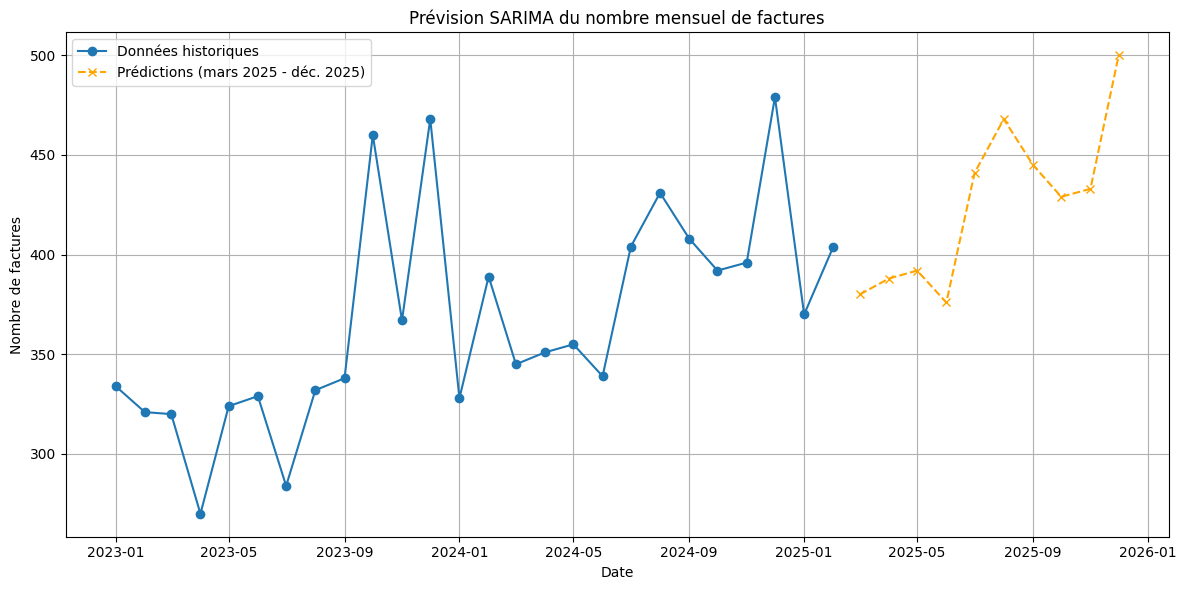

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings("ignore")

def forecast_sarima():
    # Load data
    try:
        df = pd.read_csv('out.csv', parse_dates=['Date'])
    except FileNotFoundError:
        return None
    except Exception as e:
        print(f"Error loading file: {e}")
        return None

    # Validate Date column
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    if df['Date'].isna().any():
        df = df.dropna(subset=['Date'])

    # Aggregate to monthly invoice counts
    df['year'] = df['Date'].dt.year
    df['monthofyear'] = df['Date'].dt.month
    df_agg = df.groupby(['year', 'monthofyear']).size().reset_index(name='y')
    df_agg['ds'] = pd.to_datetime(df_agg['year'].astype(str) + '-' + df_agg['monthofyear'].astype(str).str.zfill(2) + '-01')
    df_agg = df_agg.set_index('ds')['y'].asfreq('MS')


    # Exclude March 2025 (partial month)
    df_agg = df_agg[df_agg.index < '2025-03-01']

    # Handle outliers (Jan 2023)
    df_agg = df_agg.clip(lower=100)


    # Handle missing data
    if df_agg.isna().any():
        df_agg = df_agg.ffill().bfill()

    # Fit SARIMA model
    try:
        model = SARIMAX(df_agg,
                        order=(1, 1, 1),
                        seasonal_order=(0, 1, 0, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        model_fit = model.fit(disp=False, maxiter=100)
        #print("SARIMA model fitted successfully.")
    except Exception as e:
        model = SARIMAX(df_agg, order=(1, 1, 1), seasonal_order=(1, 1, 0, 12))
        model_fit = model.fit(disp=False)

    # Forecast: March to December 2025
    forecast_start = pd.to_datetime('2025-03-01')
    forecast_end = pd.to_datetime('2025-12-01')
    n_periods = (forecast_end.year - forecast_start.year) * 12 + forecast_end.month - forecast_start.month + 1
    forecast = model_fit.forecast(steps=n_periods)

    # Handle non-finite values
    last_value = df_agg.iloc[-1]
    forecast = pd.Series(forecast).fillna(last_value)
    forecast = forecast.replace([np.inf, -np.inf], last_value)

    # Create forecast series
    future_dates = pd.date_range(start=forecast_start, end=forecast_end, freq='MS')
    forecast_series = pd.Series(forecast, index=future_dates)

    # Clip forecasts to reasonable range
    forecast_series = forecast_series.clip(lower=300, upper=500)
    forecast_series = forecast_series.round().astype(int)

    # Print forecast
    print("\nPrédictions du nombre mensuel de factures (Mars 2025 - Décembre 2025):")
    for date, value in forecast_series.items():
        print(f"{date.strftime('%Y-%m')}: {value}")
# Save forecast to CSV
    forecast_df = pd.DataFrame({
        'Date': future_dates.strftime('%Y-%m'),
        'Num_Factures': forecast_series.values
    })
    forecast_df.to_csv('invoice_forecast.csv', index=False)

    # Visualization
    plt.figure(figsize=(12, 6))
    plt.plot(df_agg, label='Données historiques', marker='o')
    plt.plot(forecast_series, label='Prédictions (mars 2025 - déc. 2025)', marker='x', linestyle='--', color='orange')
    plt.title('Prévision SARIMA du nombre mensuel de factures')
    plt.xlabel('Date')
    plt.ylabel('Nombre de factures')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig('Prévision SARIMA du nombre mensuel de factures.png')
    plt.show()

    return forecast_series

# Execute the function
if __name__ == "__main__":
    forecast_sarima()

In [11]:
mean_value = test['Num_Factures'].mean()
prophet_accuracy_percentage = (1 - (prophet_mae / mean_value)) * 100
arima_accuracy_percentage = (1 - (arima_mae / mean_value)) * 100
sarima_accuracy_percentage = (1 - (sarima_mae / mean_value)) * 100

print(f"Prophet - Précision relative (basée sur MAE): {prophet_accuracy_percentage:.2f}%")
print(f"SARIMA - Précision relative (basée sur MAE): {sarima_accuracy_percentage:.2f}%")
print(f"ARIMA - Précision relative (basée sur MAE): {arima_accuracy_percentage:.2f}%")

Prophet - Précision relative (basée sur MAE): 36.17%
SARIMA - Précision relative (basée sur MAE): 73.33%
ARIMA - Précision relative (basée sur MAE): 63.55%
